In [1]:
# Enable inline plotting for matplotlib
%matplotlib inline
# Import required libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
from glob import glob
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Set base directory for Samsung watch data
samsung_base_dir = os.path.join('.', 'samsung_watch_data')
# Get list of all dump directories
samsung_dump_dirs = glob(os.path.join(samsung_base_dir, '*')) 
# Get name of first dump directory
samsung_dump_dir = os.path.basename(samsung_dump_dirs[0])
print(len(samsung_dump_dirs), 'dumps found, taking first:', samsung_dump_dir)

# Find all CSV files in the dump directory
samsung_csv_paths = glob(os.path.join(samsung_base_dir, samsung_dump_dir, '*.csv'))
print(len(samsung_csv_paths), 'csvs found')
# Find all JSON files in the jsons subdirectory
samsung_json_paths = glob(os.path.join(samsung_base_dir, samsung_dump_dir, 'jsons', '*', '*', '*.json'))
print(len(samsung_json_paths), 'jsons found')


2 dumps found, taking first: samsunghealth_pemesa01.champollion_20250604141272
26 csvs found
295 jsons found


Process CSV

In [2]:
# Import display function from IPython for displaying dataframes
from IPython.display import display

# Define lambda function to read CSV files, skipping first row and not using index
sam_read_csv = lambda x: pd.read_csv(x, skiprows=1, index_col=False)

# Create dictionary of dataframes from CSV files, removing 'com.samsung.' prefix from filenames
all_csv_df = {os.path.basename(j).replace('com.samsung.', ''): sam_read_csv(j) for j in samsung_csv_paths}

# Loop through the dataframes dictionary and display samples
for k, v in all_csv_df.items():
    print(k, 'readings:', v.shape[0])  # Print filename and number of rows
    display(v.sample(2 if v.shape[0] > 2 else 1))  # Display 2 random rows (or 1 if data has only 1 row)


shealth.badge.20250604141272.csv readings: 4


,number_of_streak,start_time,exercise_type,device_type,status,sleep_coaching_session_uuid,update_time,create_time,source_pkg_name,key,program_id,is_shown,time_offset,extra_data,deviceuuid,pkg_name,exercise_data_uuid,controller_id,end_time,datauuid
2,NaN,2025-05-15 00:00:00.000,NaN,NaN,1,NaN,2025-05-19 07:57:12.006,2025-05-19 07:57:12.006,NaN,vitality_first_measure,NaN,NaN,UTC+0000,NaN,6ELqGFWjt8,com.sec.android.app.shealth,NaN,tracker.vitality,2025-05-15 00:00:00.000,7cd49ea9-dc50-40f2-b0ad-121ba3d158a3
0,1.0,2025-05-14 22:00:00.000,NaN,NaN,1,NaN,2025-05-19 07:57:10.158,2025-05-19 07:57:10.158,NaN,sleep_good_sleep,NaN,NaN,UTC+0200,NaN,6ELqGFWjt8,com.sec.android.app.shealth,NaN,Sleep.Goal,2025-05-15 21:59:59.999,0f4c1708-0517-401b-a1a3-ee1ee23f3b88


shealth.social.service_status.20250604141272.csv readings: 3


,status,update_time,create_time,service_type,deviceuuid,pkg_name,datauuid
1,0,2025-05-14 16:20:27.254,2025-05-14 16:20:27.254,2,6ELqGFWjt8,com.sec.android.app.shealth,774ae820-fc30-4834-b713-c98da02e742b
0,0,2025-05-14 16:20:27.253,2025-05-14 16:20:27.253,1,6ELqGFWjt8,com.sec.android.app.shealth,8d95779b-7982-4382-9c5e-f3f4267ecf12


shealth.tracker.heart_rate.20250604141272.csv readings: 163


...

,create_sh_ver,start_time,custom,binning_data,modify_sh_ver,update_time,create_time,time_offset,deviceuuid,comment,pkg_name,end_time,datauuid
0,62910051,2025-05-14 22:00:00.000,NaN,da9b6ec3-43f2-4427-a9de-82bf915c7925.binning_d...,62910051,2025-05-14 23:15:00.672,2025-05-14 23:15:00.672,UTC+0200,HFrhKp8clb,NaN,com.sec.android.app.shealth,2025-05-14 23:00:00.000,da9b6ec3-43f2-4427-a9de-82bf915c7925
3,62910051,2025-05-15 01:00:00.000,NaN,e0febec5-e414-49b7-b43d-3de8b8ed9bc2.binning_d...,62910051,2025-05-15 02:15:00.191,2025-05-15 02:15:00.191,UTC+0200,HFrhKp8clb,NaN,com.sec.android.app.shealth,2025-05-15 02:00:00.000,e0febec5-e414-49b7-b43d-3de8b8ed9bc2


shealth.service_preferences.20250604141272.csv readings: 6


,text_value,service_id,float_value,update_time,create_time,long_value,key,tag,blob_value,int_value,deviceuuid,pkg_name,double_value,datauuid
4,NaN,app.settings,NaN,2025-06-04 08:50:00.427,2025-05-14 10:05:50.812,NaN,psm_plus_enable,NaN,NaN,0.0,HFrhKp8clb,com.sec.android.app.shealth,NaN,psm_plus_enable
0,NaN,NaN,NaN,2025-05-14 16:20:25.392,2025-05-14 16:20:25.392,NaN,oobe.completed,NaN,NaN,1.0,6ELqGFWjt8,com.sec.android.app.shealth,NaN,925a90a8-da28-43d3-a935-f76ad6d9c63c


health.movement.20250604141272.csv readings: 47


,create_sh_ver,start_time,custom,binning_data,modify_sh_ver,update_time,create_time,time_offset,deviceuuid,comment,pkg_name,end_time,datauuid
6,62910051,2025-05-14 16:00:00.000,NaN,df1174b2-e82f-46a6-b836-61ce0a75ccd4.binning_d...,62910051,2025-05-14 17:07:32.403,2025-05-14 16:07:19.884,UTC+0200,HFrhKp8clb,NaN,com.sec.android.app.shealth,2025-05-14 16:59:59.999,df1174b2-e82f-46a6-b836-61ce0a75ccd4
40,62980011,2025-05-29 06:59:00.000,NaN,69f35ac6-3096-490a-9536-3a7b92b25795.binning_d...,62980011,2025-05-29 07:03:42.042,2025-05-29 07:03:42.042,UTC+0200,HFrhKp8clb,NaN,com.sec.android.app.shealth,2025-05-29 06:59:59.999,69f35ac6-3096-490a-9536-3a7b92b25795


Step counts

In [3]:
# Concatenate all dataframes containing 'step_daily_trend' in their keys
step_df = pd.concat([v for k, v in all_csv_df.items() if 'step_daily_trend' in k])

# Convert create_time and update_time columns to datetime format
for c_col in ['create_time', 'update_time']:
    step_df[c_col] = pd.to_datetime(step_df[c_col])

# Sort values by create_time in ascending order
step_df = step_df.sort_values('create_time', ascending=True)
pd.to_datetime(step_df['create_time'])
step_df.head(3)


,binning_data,update_time,create_time,source_pkg_name,source_type,count,speed,distance,calorie,deviceuuid,pkg_name,datauuid,day_time
0,10f99b2a-e91f-4c99-90db-465edadefa74.binning_d...,2025-05-19 07:56:48.284,2025-05-14 16:20:39.691,com.sec.android.app.shealth,-2,4899,1.345365,3696.65,174.81,VfS0qUERdZ,com.sec.android.app.shealth,10f99b2a-e91f-4c99-90db-465edadefa74,1747180800000
1,54465d37-c800-4f83-9582-f52d712b9bf8.binning_d...,2025-05-19 07:56:52.012,2025-05-14 16:20:49.132,com.sec.android.app.shealth,108,4899,1.345365,3696.65,174.81,HFrhKp8clb,com.sec.android.app.shealth,54465d37-c800-4f83-9582-f52d712b9bf8,1747180800000
2,23c0c595-4c7a-4655-9eb0-d798ed9ab638.binning_d...,2025-05-22 07:47:25.304,2025-05-19 07:56:46.469,com.sec.android.app.shealth,-2,3265,1.257359,2426.09,121.52,VfS0qUERdZ,com.sec.android.app.shealth,23c0c595-4c7a-4655-9eb0-d798ed9ab638,1747612800000


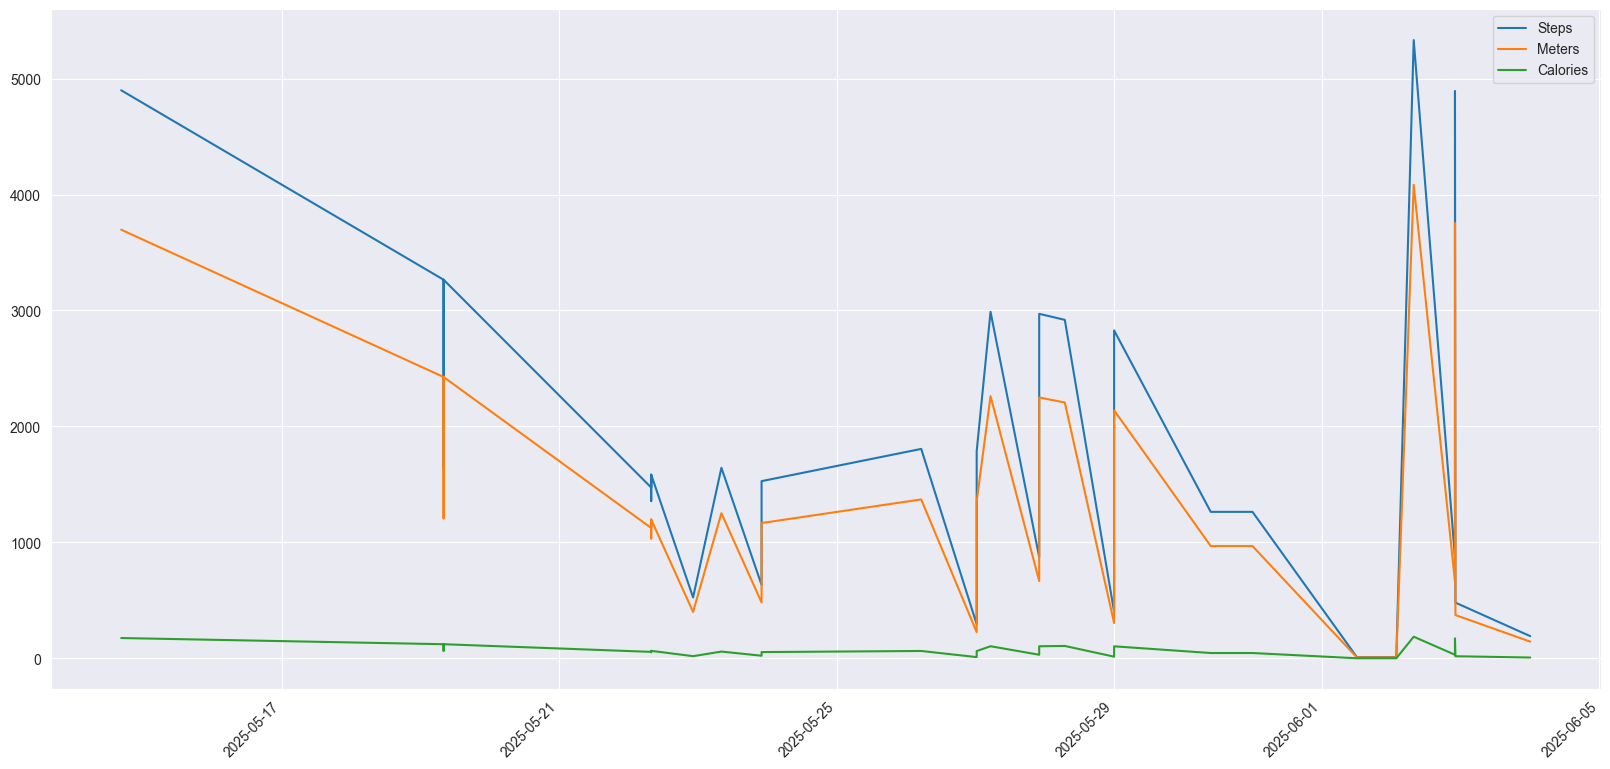

In [4]:
# Create a figure with one subplot, size 20x10 inches
fig, ax1 = plt.subplots(1, 1, figsize=(20, 10))
# Plot steps count over time
ax1.plot(step_df['create_time'], step_df['count'], '-', label='Steps')
# Plot distance in meters over time
ax1.plot(step_df['create_time'], step_df['distance'], '-', label='Meters')
# Plot calories burned over time
ax1.plot(step_df['create_time'], step_df['calorie'], '-', label='Calories')
# Add legend to show what each line represents
ax1.legend()
# Rotate x-axis date labels by 45 degrees for better readability
fig.autofmt_xdate(rotation=45)


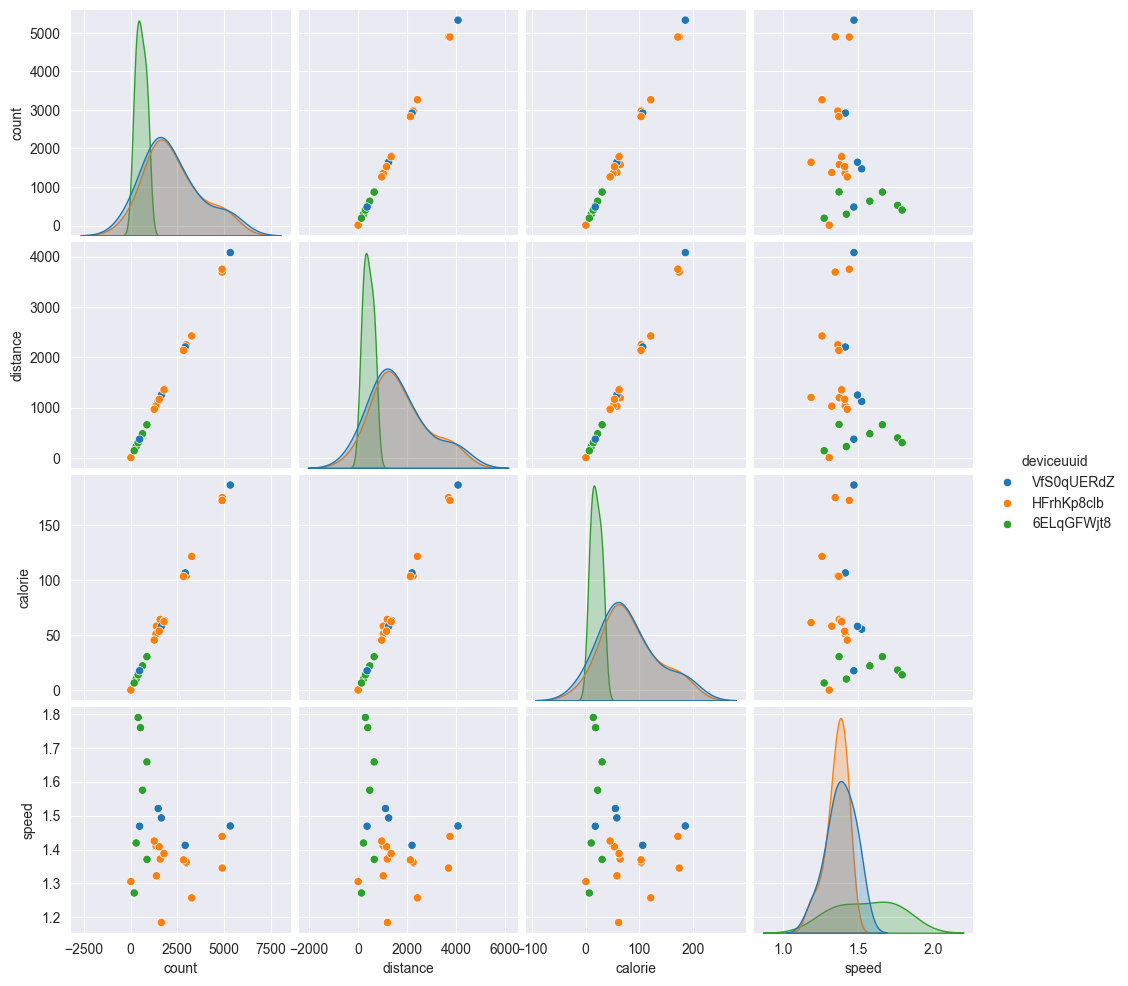

In [5]:
sns.pairplot(hue = 'deviceuuid', data = step_df[['count', 'distance', 'calorie', 'speed', 'deviceuuid']])

Day of week

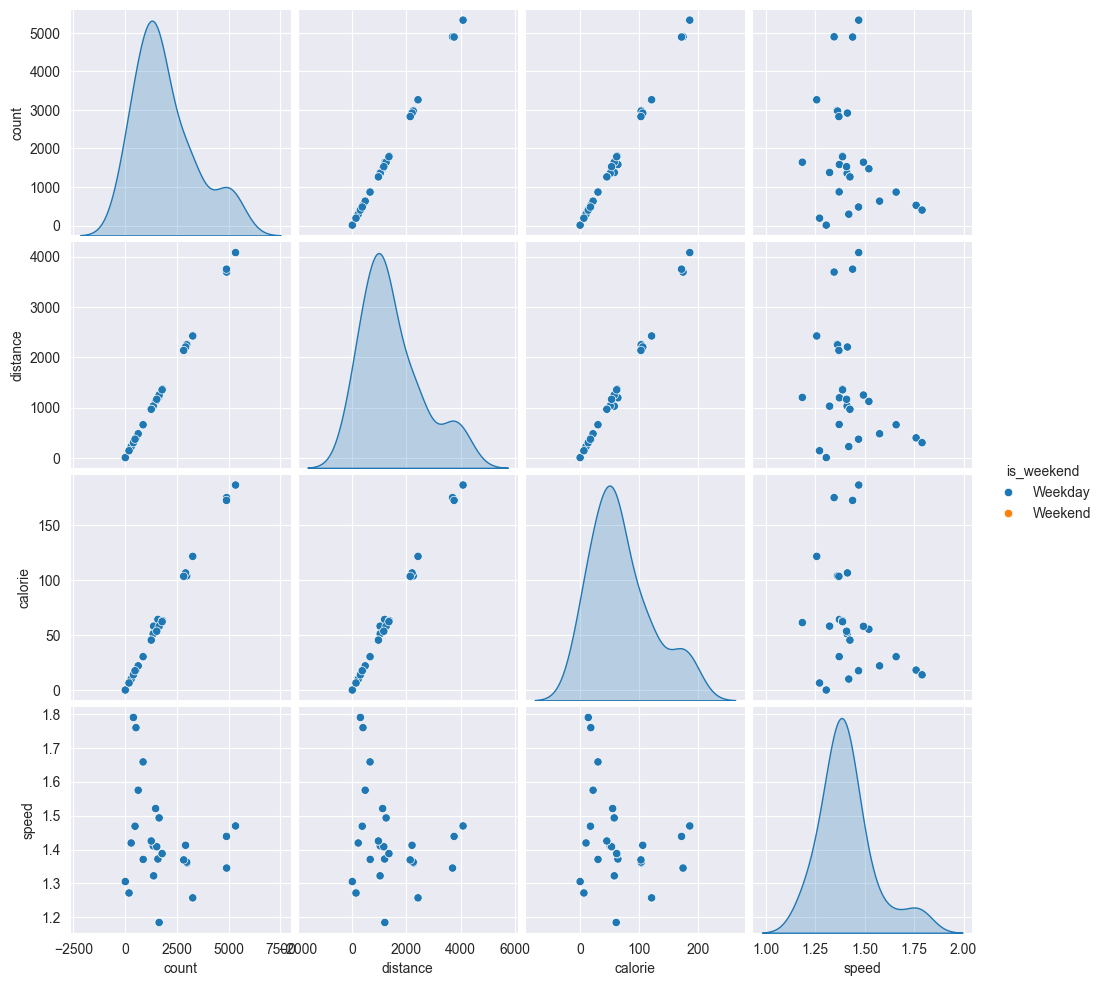

In [6]:
step_df['day_name'] = step_df['create_time'].dt.day_name()
step_df['is_weekend'] = step_df['day_name'].map(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')
sns.pairplot(hue = 'is_weekend', data = step_df[['count', 'distance', 'calorie', 'speed', 'day_name', 'is_weekend']])


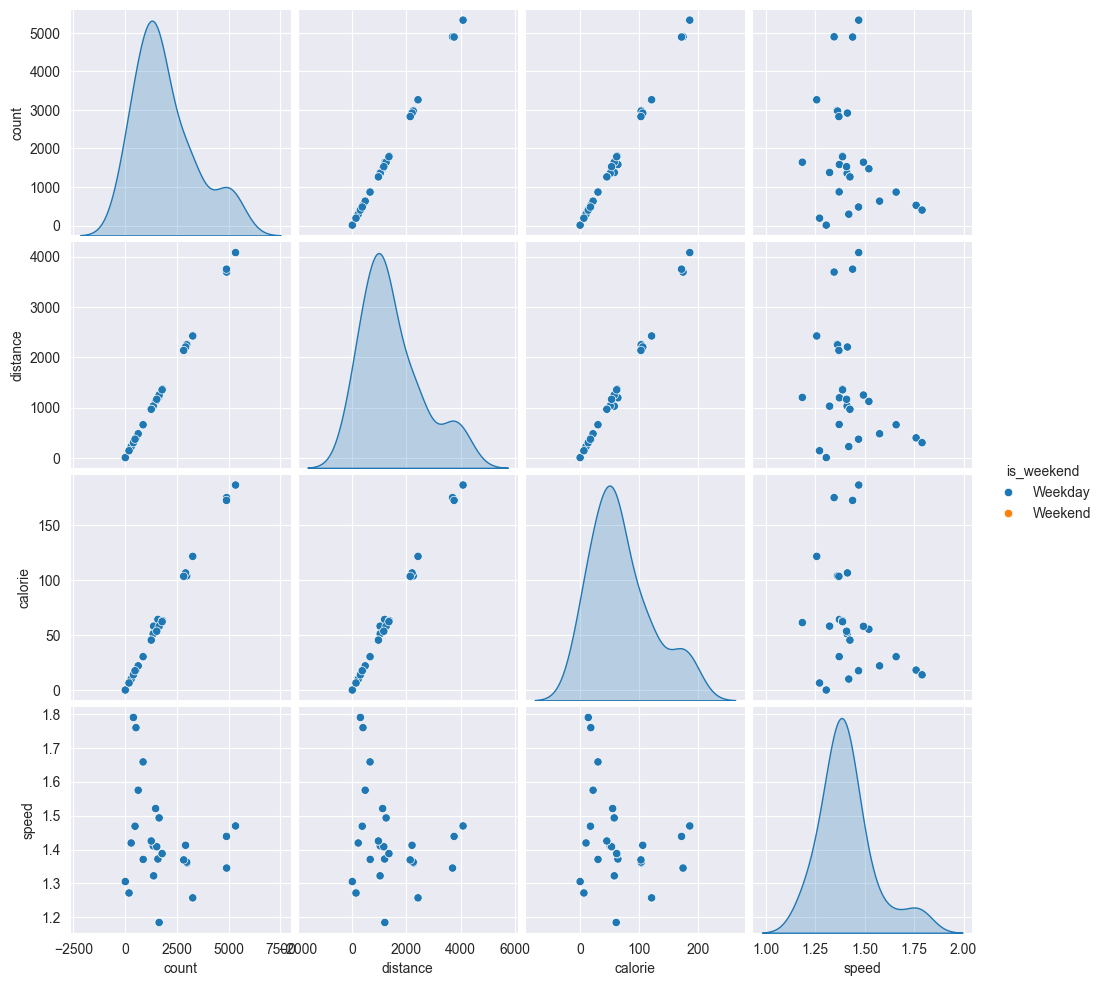

In [7]:
step_df['day_name'] = step_df['create_time'].dt.day_name()
step_df['is_weekend'] = step_df['day_name'].map(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')
sns.pairplot(hue = 'is_weekend', data = step_df[['count', 'distance', 'calorie', 'speed', 'day_name', 'is_weekend']])


In [8]:
# Import necessary libraries for handling JSON files and iterables
from itertools import groupby, chain
import json

# Initialize empty dictionary to store JSON data
sam_json_dict = {}

# Group JSON files by folder name (removing 'com.samsung.' prefix)
for fold_id, files in groupby(samsung_json_paths,
                              lambda x: os.path.basename(os.path.dirname(x)[:-2]).replace('com.samsung.', '')):
    # Convert iterator to list
    c_files = list(files)

    # Load and parse JSON data from each file
    c_json_data = [json.load(open(c_file, 'r')) for c_file in c_files]
    # Chain lists together if data is list, otherwise keep as is
    sam_json_dict[fold_id] = list(chain(*c_json_data)) if isinstance(c_json_data[0], list) else c_json_data
    # Print summary info about the loaded data
    print(fold_id + ',', 'files:', len(c_files), 'readings:', len(sam_json_dict[fold_id]))
    print('\tPreview:', str(sam_json_dict[fold_id][0])[:80])


health.advanced_glycation_endproduct, files: 1 readings: 5
	Preview: 118
health.advanced_glycation_endproduct.raw, files: 1 readings: 7
	Preview: {'timestamp': 1747263600022, 'score': 160}
health.device_profile, files: 1 readings: 1
	Preview: {'capability_type': 'com.samsung.shealth.RESPONSE_CAPABILITY', 'sender': 'wearab
health.floors_climbed, files: 11 readings: 12
	Preview: {'end_time': 1748415377000, 'floor': 1.0}
health.hrv, files: 8 readings: 851
	Preview: {'start_time': 1747274428454, 'end_time': 1747274730260, 'sdnn': 47.6511, 'rmssd
health.movement, files: 48 readings: 2629
	Preview: {'start_time': 1747288800000, 'end_time': 1747288859999, 'activity_level': 62.50
health.user_profile, files: 1 readings: 1
	Preview: {'mHServiceIdList': [{'mClient': 'tracker.vitality', 'mProvider': 'com.sec.andro
shealth.activity.day_summary, files: 44 readings: 44
	Preview: {'mAdaptiveGoal': 0, 'mIsGoalAchieved': False, 'mIsMostActiveAchieved': False, '
shealth.calories_burned.details, files: 48

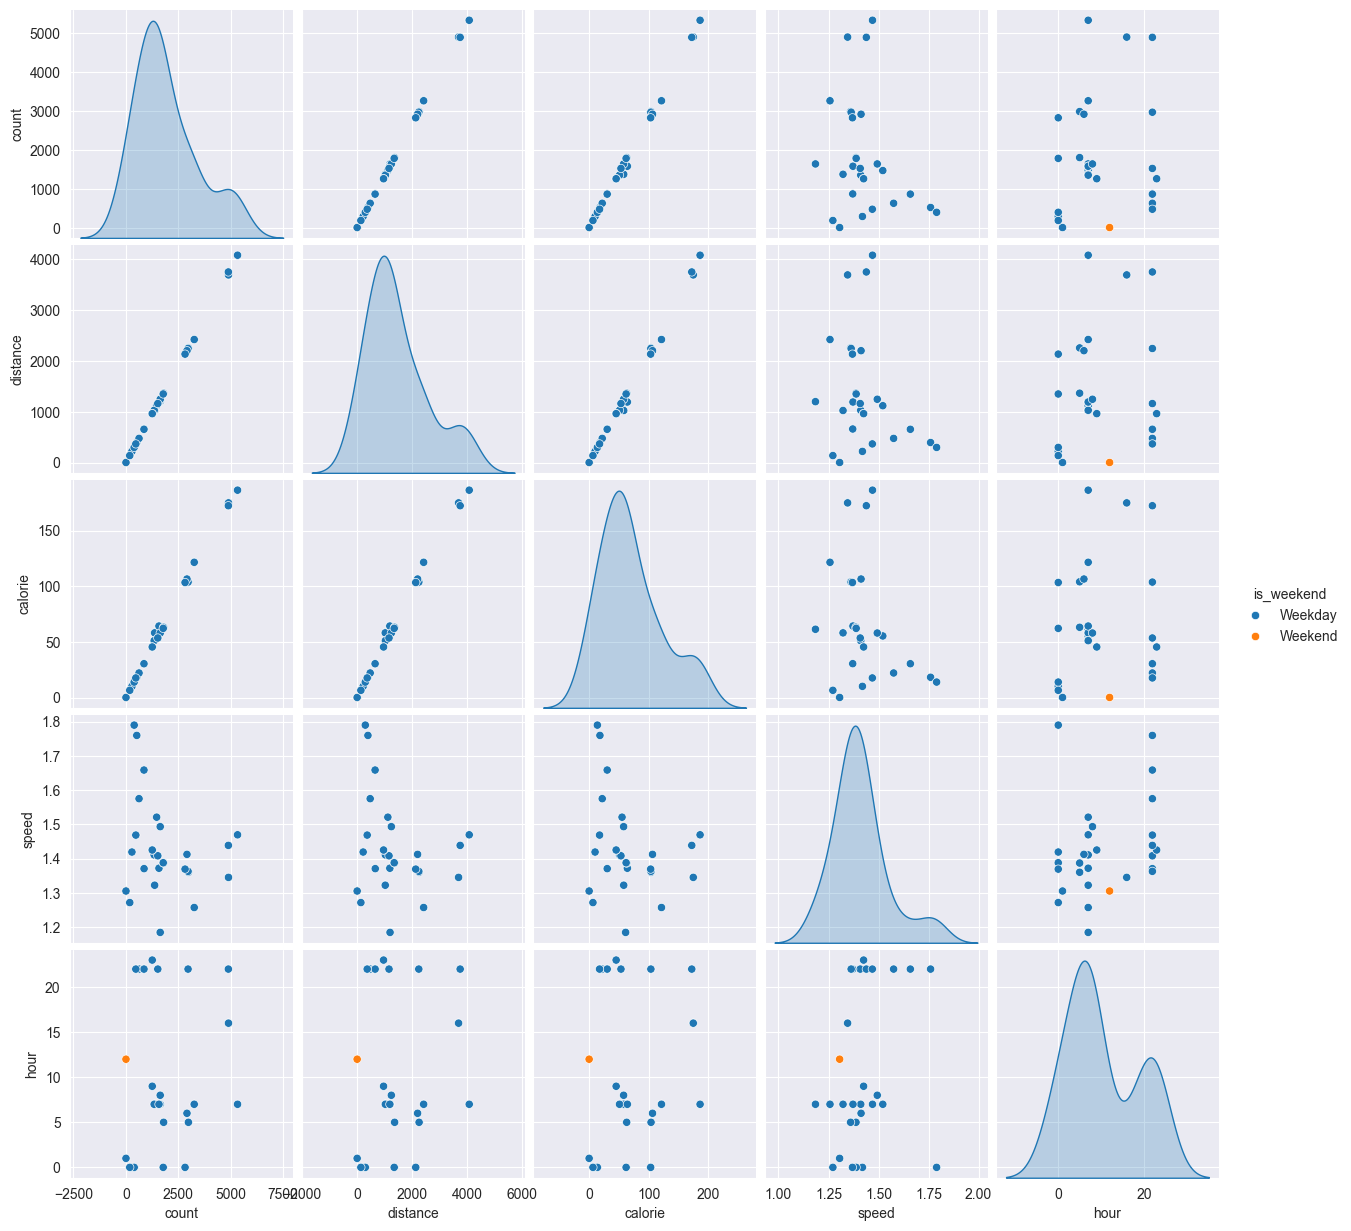

In [9]:
step_df['hour'] = step_df['create_time'].dt.hour
sns.pairplot(hue = 'is_weekend', data = step_df[['count', 'distance', 'calorie', 'speed', 'hour', 'is_weekend']])

In [10]:
stress_df = pd.DataFrame(sam_json_dict['shealth.stress'])
sns.pairplot(stress_df)

KeyError: 'shealth.stress'